Regiones y fronteras 

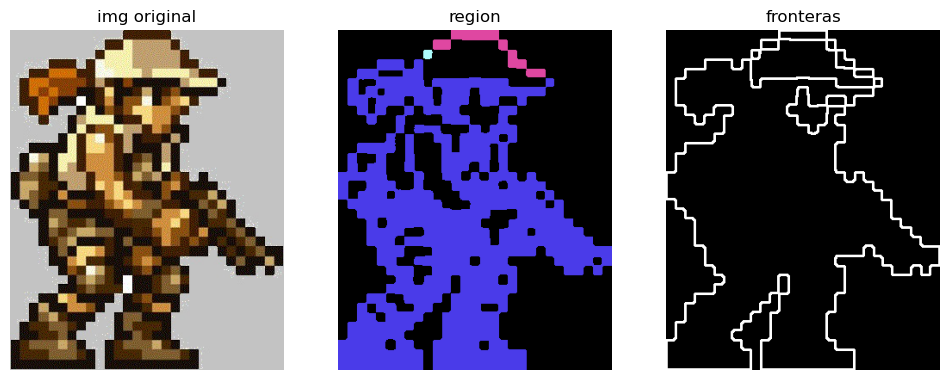

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imag1JPEG.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(imgGray,(7,7),0)
_,binarizada = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#regiones
cant,region = cv2.connectedComponents(binarizada)

colores = np.random.randint(0,255,size=(cant,3),dtype=np.uint8)

colores[0] = [0,0,0]
color_regionb = colores[region]

#fronteras

contorno,_= cv2.findContours(binarizada,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
lineas = cv2.drawContours(np.zeros_like(imgGray),contorno,-1,255,2)

plt.figure(figsize=(12,10))
plt.subplot(1,3,1)
plt.title('img original')
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('region')
plt.imshow(color_regionb)
plt.axis('off')

plt.subplot(1,3,3)
plt.title('fronteras')
plt.imshow(lineas, cmap='gray')
plt.axis('off')

plt.show()

distancias

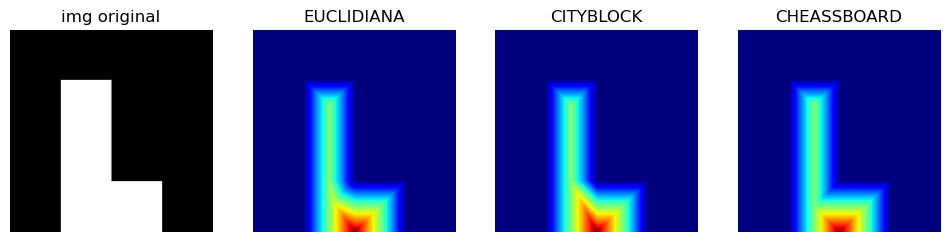

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((200,200),dtype = np.uint8)
img[50:250,50:100] = 1
img[150:250,50:150] = 1

def distancia(imgBinarizada):
    invertir = 1-imgBinarizada

    #EUCLIDIANA
    dist_eucli = cv2.distanceTransform(imgBinarizada,cv2.DIST_L2,3)

    #CITYBLOCK
    dist_city = cv2.distanceTransform(imgBinarizada,cv2.DIST_L1,3)

    #CHEASSBOARD
    dist_chea = cv2.distanceTransform(imgBinarizada,cv2.DIST_C,3)

    return dist_eucli,dist_city,dist_chea

def normalizar(dist):
    return cv2.normalize(dist,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

eucli,city,chess = distancia(img)
normEucli = normalizar(eucli)
normCity = normalizar(city)
normChess = normalizar(chess)


plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.title('img original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('EUCLIDIANA')
plt.imshow(normEucli, cmap='jet')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('CITYBLOCK')
plt.imshow(normCity, cmap='jet')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('CHEASSBOARD')
plt.imshow(normChess, cmap='jet')
plt.axis('off')

plt.show()

Contadores-
comando
(conda install scikit-image)

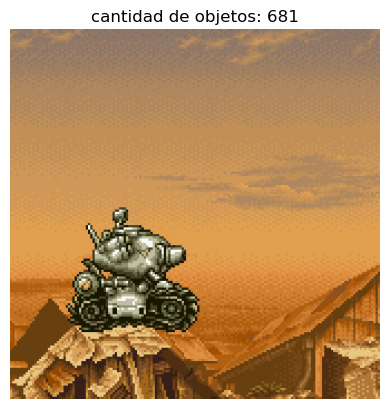

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(imagen):
    gray = cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    _,binarizar = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
    etiquetar = measure.label(binarizar,connectivity=2)# conectividad con 4 = 2 y conectividad con 8 = 1
    num = np.max(etiquetar)
    return num 


imagen = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

contar1 = contar(imagen)

plt.imshow(imgRGB)
plt.title(f'cantidad de objetos: {contar1}')
plt.axis('off')

plt.show()

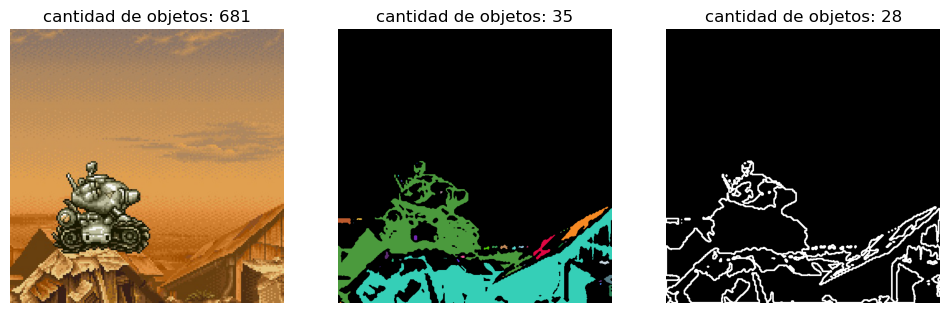

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar(imagen):
    _,binarizar = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
    etiquetar = measure.label(binarizar,connectivity=2)# conectividad con 4 = 2 y conectividad con 8 = 1
    num = np.max(etiquetar)
    return num 



img = cv2.imread('imgGIF3.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(imgGray,(7,7),0)
_,binarizada = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
#regiones
cant,region = cv2.connectedComponents(binarizada)

colores = np.random.randint(0,255,size=(cant,3),dtype=np.uint8)

colores[0] = [0,0,0]
color_regionb = colores[region]

#fronteras

contorno,_= cv2.findContours(binarizada,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
lineas = cv2.drawContours(np.zeros_like(imgGray),contorno,-1,255,2)

contar1 = contar(imgGray)
contar2 = contar(color_regionb)
contar3 = contar(lineas)

plt.figure(figsize=(12,10))
plt.subplot(1,3,1)
plt.title('img original')
plt.title(f'cantidad de objetos: {contar1}')
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(1,3,2)
plt.title('region')
plt.imshow(color_regionb)
plt.title(f'cantidad de objetos: {contar2}')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('fronteras')
plt.imshow(lineas, cmap='gray')
plt.title(f'cantidad de objetos: {contar3}')
plt.axis('off')

plt.show()

Etiquetado

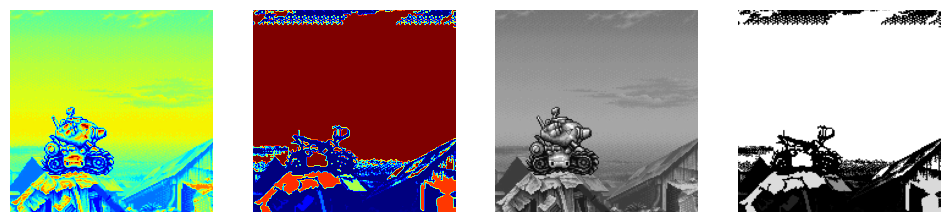

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def etiquetar(img):
    _,imgBIN=cv2.threshold(img,127,255,cv2.THRESH_BINARY)

    contorno,_=cv2.findContours(imgBIN,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    imgEtq = np.zeros_like(img,dtype=np.uint8)

    for i,contornos in enumerate(contorno):
        cv2.drawContours(imgEtq,[contornos],-1,(i+1),-1)
    return imgEtq
    
img = cv2.imread('imgGIF3.jpg',0)
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

imgEtq = etiquetar(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.imshow(img, cmap='jet')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(imgEtq, cmap='jet')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(imgEtq, cmap='gray')
plt.axis('off')

plt.show()

Etiquetado con label

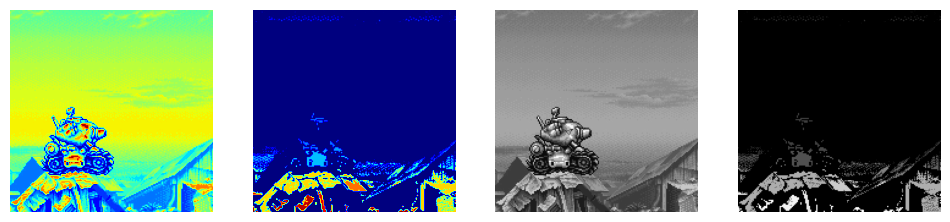

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imgGIF3.jpg',0)
_,imgBIN=cv2.threshold(img,127,255,cv2.THRESH_BINARY)
imgEtq = measure.label(imgBIN,connectivity=2)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.imshow(img, cmap='jet')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(imgEtq, cmap='jet')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(imgEtq, cmap='gray')
plt.axis('off')

plt.show()

Conteo

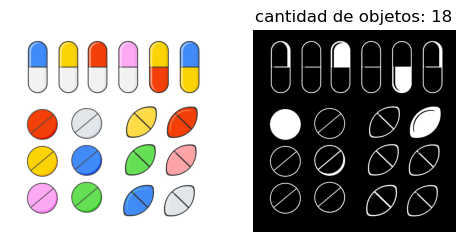

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def conteo(img):
    imgGray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binarizar = cv2.threshold(imgGray,127,255,cv2.THRESH_BINARY_INV)
    borde,_ = cv2.findContours(binarizar,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    cont=len(borde)
    return cont,binarizar

img = cv2.imread('contar1.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgCont,bin=conteo(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(bin, cmap='gray')
plt.title(f'cantidad de objetos: {imgCont}')
plt.axis('off')

plt.show()

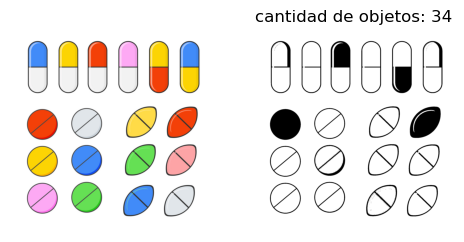

In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def conteo2(img):
    imgGray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binarizar = cv2.threshold(imgGray,127,255,cv2.THRESH_BINARY)
    contorno = measure.label(binarizar,connectivity=2)
    cont = np.max(contorno)

    return cont,binarizar


img = cv2.imread('contar1.jpg')
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgCont,bin=conteo2(img)

plt.figure(figsize=(12,10))
plt.subplot(1,4,1)
plt.imshow(imgRGB)
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(bin, cmap='gray')
plt.title(f'cantidad de objetos: {imgCont}')
plt.axis('off')

plt.show()